## 1.Load dataset and check fraud vs non-fraud counts to understand imbalance.

In [82]:
import pandas as pd

In [83]:
df = pd.read_csv('bank-full.csv',sep=';')

In [84]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [85]:
df.rename(columns={"y":"Detection"},inplace=True)

In [86]:
df['Detection'] = df['Detection'].map({'no':'not fraud','yes':'fraud'})

In [87]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Detection
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,not fraud
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,not fraud
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,not fraud
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,not fraud
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,not fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,fraud
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,fraud
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,fraud
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,not fraud


In [88]:
dia= df['Detection'].value_counts()

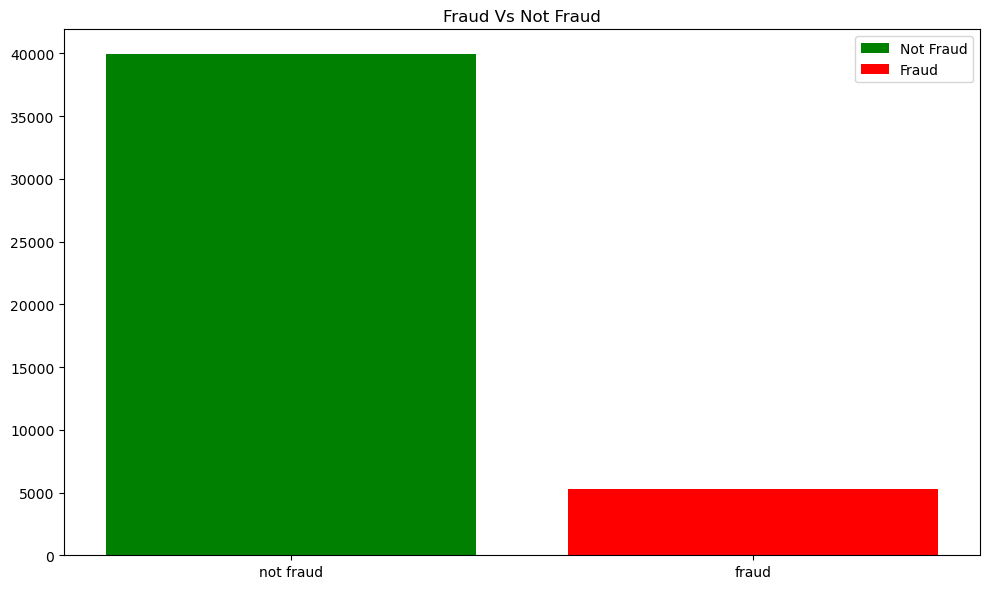

In [89]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(dia.index,dia.values,label=['Not Fraud','Fraud'],color=['green','red'])
plt.title('Fraud Vs Not Fraud')
plt.legend()
plt.tight_layout()


## 2.Split dataset using stratified sampling so fraud ratio stays similar in train and test

#### Here manually Split

In [90]:
import numpy as np
def shuffle_and_split(data,test_ratio):
    np.random.seed(42)
    shuffle_indices = np.random.permutation(len(data))
    test_set_size = int(len(data)*test_ratio)
    test_indices = shuffle_indices[:test_set_size]
    train_indices = shuffle_indices[test_set_size:]
    return data.iloc[train_indices],data.iloc[test_indices]



#### Sklearn stratified split

In [91]:
from sklearn.model_selection import StratifiedShuffleSplit

In [92]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_set,test_set in split.split(df,df['Detection']):
    strat_train_set =  df.loc[train_set]
    strat_test_set = df.loc[test_set]

In [93]:
strat_train_set

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Detection
14069,51,technician,married,secondary,no,58,yes,no,cellular,11,jul,128,2,-1,0,unknown,not fraud
18630,32,blue-collar,married,secondary,no,139,yes,yes,cellular,31,jul,70,5,-1,0,unknown,not fraud
8823,37,blue-collar,married,secondary,no,117,yes,no,unknown,4,jun,52,1,-1,0,unknown,not fraud
21936,46,blue-collar,married,secondary,no,15,yes,yes,cellular,20,aug,76,3,-1,0,unknown,not fraud
12242,36,blue-collar,divorced,secondary,no,1237,yes,no,unknown,20,jun,310,2,-1,0,unknown,not fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11743,48,entrepreneur,divorced,tertiary,no,0,yes,yes,unknown,20,jun,139,1,-1,0,unknown,not fraud
40700,63,retired,married,tertiary,no,8103,no,no,cellular,7,aug,258,1,-1,0,unknown,not fraud
26147,52,management,single,tertiary,no,638,yes,yes,cellular,20,nov,77,2,-1,0,unknown,not fraud
23805,32,management,married,tertiary,no,134,no,yes,cellular,29,aug,162,2,-1,0,unknown,not fraud


In [94]:
strat_test_set

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Detection
19167,51,services,married,secondary,no,434,no,no,cellular,5,aug,513,2,-1,0,unknown,not fraud
45097,61,self-employed,married,tertiary,no,10861,no,no,cellular,25,oct,225,1,91,5,success,fraud
6664,31,technician,married,secondary,yes,-463,yes,no,unknown,28,may,210,1,-1,0,unknown,not fraud
34267,36,management,single,tertiary,no,1876,no,no,cellular,4,may,150,1,-1,0,unknown,not fraud
522,52,admin.,married,secondary,no,484,yes,no,unknown,6,may,128,1,-1,0,unknown,not fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,54,blue-collar,divorced,primary,no,8180,no,no,unknown,19,may,312,1,-1,0,unknown,not fraud
37497,44,admin.,divorced,tertiary,no,994,yes,no,cellular,13,may,420,3,-1,0,unknown,not fraud
34426,32,student,single,tertiary,no,290,yes,no,cellular,5,may,18,6,-1,0,unknown,not fraud
4444,36,blue-collar,married,secondary,no,7579,yes,no,unknown,20,may,600,1,-1,0,unknown,not fraud


## 3.Separate features and target column and remove non-useful identifiers.


In [95]:
feature_train = strat_train_set.drop('Detection',axis=1)
feature_test = strat_test_set.drop('Detection',axis=1)
labels_train = strat_train_set['Detection']
labels_test = strat_test_set['Detection']

## 4.Train a baseline model like Logistic Regression for comparison.


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

In [97]:
onehot = OneHotEncoder(handle_unknown='ignore')
feature_train_num = onehot.fit_transform(feature_train)
feature_test_num = onehot.transform(feature_test)

In [98]:
model = LogisticRegression()

In [99]:
model.fit(feature_train_num,labels_train)

C:\Users\ddeba\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [100]:
prediction = model.predict(feature_test_num)

In [101]:
prediction

array(['not fraud', 'fraud', 'not fraud', ..., 'not fraud', 'not fraud',
       'not fraud'], dtype=object)

In [123]:
from sklearn.metrics import accuracy_score

# One-liner for the win
accuracy_l = accuracy_score(labels_test, prediction)
print(f"Accuracy of l Logistic Regression: {accuracy_l * 100:.2f}%")

Accuracy of l Logistic Regression: 89.74%


## Accuracy of l Logistic Regression: 89.74%

## 5.Train Random Forest model with parameters like n_estimators=100.


In [103]:
from sklearn.ensemble import RandomForestClassifier

In [104]:
random_model= RandomForestClassifier(n_estimators=100)

In [105]:
random_model.fit(feature_train_num,labels_train)

RandomForestClassifier()

In [106]:
prediction_random = random_model.predict(feature_test_num)

In [107]:
prediction

array(['not fraud', 'fraud', 'not fraud', ..., 'not fraud', 'not fraud',
       'not fraud'], dtype=object)

In [124]:
from sklearn.metrics import accuracy_score

# One-liner for the win
accuracy_r = accuracy_score(labels_test, prediction_random)
print(f"Accuracy of l Logistic Regression: {accuracy_r * 100:.2f}%")

Accuracy of l Logistic Regression: 89.52%


## Accuracy of l Logistic Regression: 89.52%

## 6.Predict and evaluate using precision, recall, F1-score instead of accuracy.


##### 1. Logistic 

In [109]:
from sklearn.metrics import classification_report

In [120]:
print(classification_report(labels_test,prediction))

              precision    recall  f1-score   support

       fraud       0.65      0.27      0.38      1058
   not fraud       0.91      0.98      0.94      7985

    accuracy                           0.90      9043
   macro avg       0.78      0.63      0.66      9043
weighted avg       0.88      0.90      0.88      9043



##### 2. Random

In [121]:
print(classification_report(labels_test,prediction_random))

              precision    recall  f1-score   support

       fraud       0.74      0.16      0.27      1058
   not fraud       0.90      0.99      0.94      7985

    accuracy                           0.90      9043
   macro avg       0.82      0.58      0.60      9043
weighted avg       0.88      0.90      0.86      9043



## 7.Plot feature importances to identify key fraud indicators

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

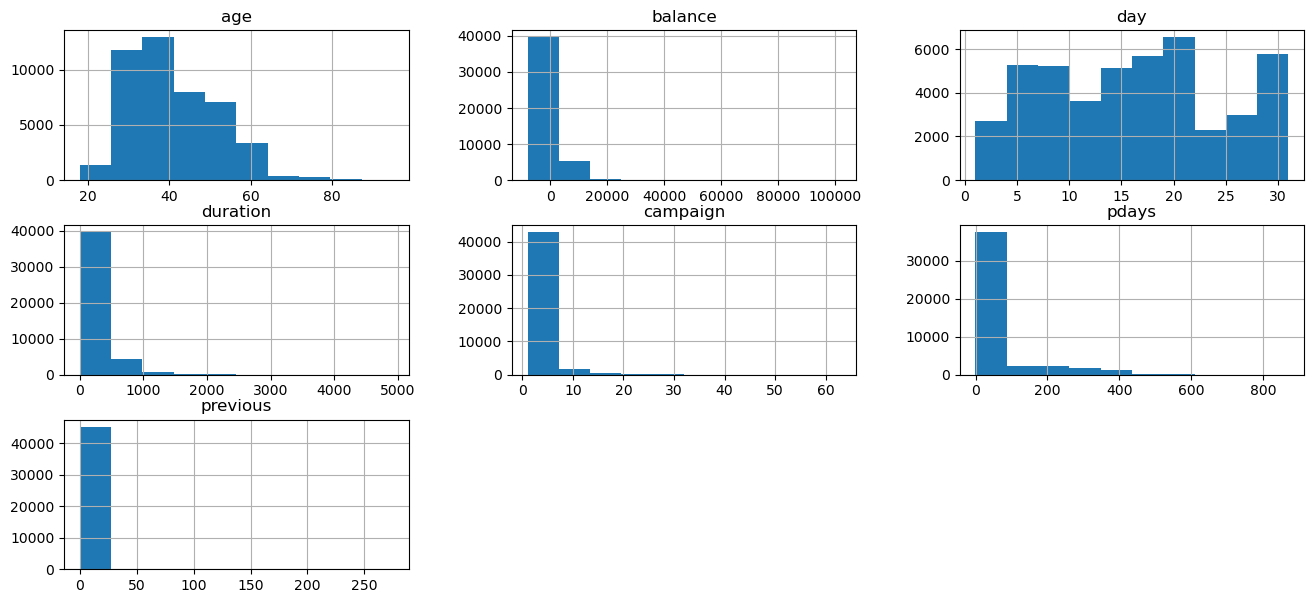

In [122]:
df.hist(figsize=(16,7))

## 8.Compare Random Forest performance against baseline model.


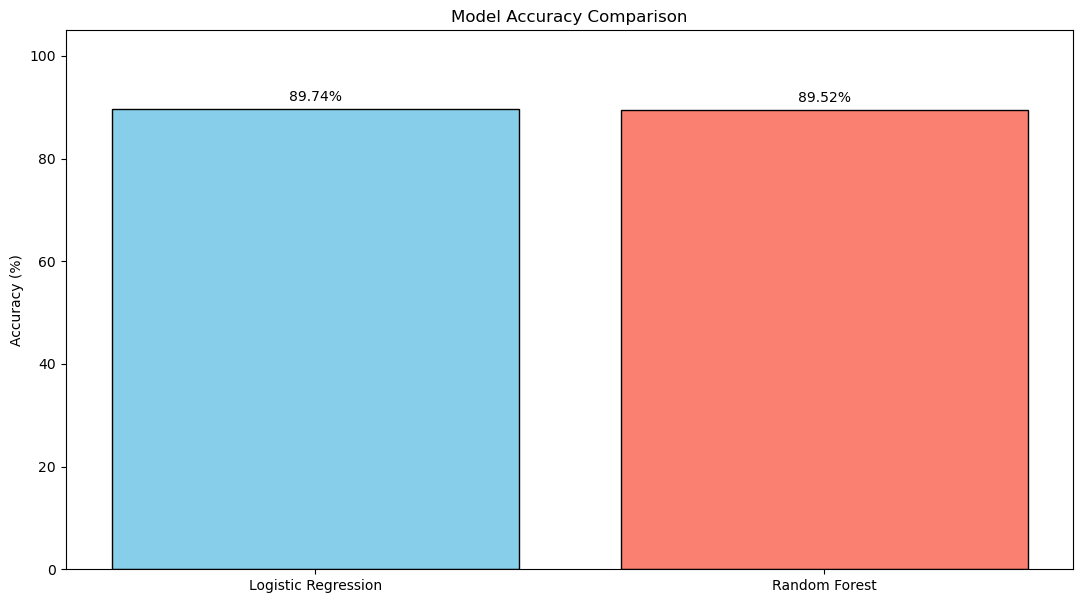

In [132]:
import matplotlib.pyplot as plt

# Data for the diagram
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_l * 100, accuracy_r * 100]  # Converting to percentage

# Create the bar chart
plt.figure(figsize=(13, 7))
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon'], edgecolor='black')

# Add labels and title
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 105)  # Leave room for text labels

# Add accuracy values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')

plt.show()


## 9.Save best model using joblib for reuse

In [134]:
import joblib
joblib.dump(model,'logistic.pkl')

['logistic.pkl']